# GPT-2 Large & Llama 3.1 8B — Semantic Similarity Results

## Research question

Can causal (left-to-right) language models recover word sense structure well enough to rival bidirectional encoders on human-elicited semantic similarity benchmarks, when equipped with a multi-prototype representation strategy?

This notebook assembles and compares results across three embedding strategies applied to two decoder-only LLMs:

| Strategy | Description |
|---|---|
| **Non-contextual** | Word embedded in isolation; no surrounding sentence |
| **Simple context** | Word embedded in a fixed template sentence; single vector per word |
| **Multi-prototype (MaxSim)** | Word embedded across many BNC corpus sentences; K-means clusters capture distinct senses |

The multi-prototype method replicates [Chronis & Erk (2020)](https://aclanthology.org/2020.conll-1.7), which originally applied this approach to BERT-base. Our contribution is applying the same pipeline to GPT-2 Large (774M parameters, causal decoder) and Llama 3.1 8B (8B parameters, causal decoder), and evaluating against both SimLex-999 (semantic similarity) and MEN (semantic relatedness).

## Workflow

All embedding computation and clustering happen in the two upstream notebooks:
- `gpt2_cluster_analysis.ipynb` — GPT-2 Large embeddings, K-means sweep, per-layer ρ
- `llama_cluster_analysis.ipynb` — Llama 3.1 8B embeddings, K-means sweep, per-layer ρ

This notebook only loads the saved CSVs and computes summary statistics.

**Expected CSVs (run the cluster notebooks first):**
- `results_gpt2_nonctx.csv`, `results_llama_nonctx.csv` — non-contextual baselines (layer 0 and final)
- `results_gpt2_simple_simlex.csv`, `results_gpt2_simple_men.csv` — GPT-2 simple template, per-layer ρ
- `results_llama_simple_simlex.csv`, `results_llama_simple_men.csv` — Llama simple template, per-layer ρ
- `results_gpt2_simlex.csv`, `results_gpt2_men.csv` — GPT-2 K × layer MaxSim heatmaps
- `results_llama_simlex.csv`, `results_llama_men.csv` — Llama K × layer MaxSim heatmaps

In [1]:
import os
import csv
import torch
import datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine
from tqdm.auto import tqdm
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
## Load Datasets

We evaluate on two standard word-pair benchmarks that measure different aspects of lexical meaning:

### SimLex-999 (Hill et al., 2015)
- **999 word pairs** (333 noun, 333 verb, 333 adjective pairs)
- Measures **semantic similarity**: the degree to which two words can *substitute* for each other in context (e.g., *cat* ≈ *kitten*, but *cat* ≉ *mouse*)
- Human annotators were explicitly instructed to distinguish similarity from association/relatedness
- Scores range from 0–10; the benchmark Spearman correlation is computed against model cosine similarities
- Considered a harder benchmark for distributional models because relatedness cues (co-occurrence) do not directly signal similarity

### MEN (Bruni et al., 2014)
- **3,000 word pairs** drawn from a diverse vocabulary
- Measures **semantic relatedness**: a broader notion that includes association, taxonomic, and topical links (e.g., *coffee* ~ *cup* or *beach* ~ *ocean*)
- Annotated via pairwise ranking by crowd-sourced workers; scores normalized to [0, 50]
- Relatedness is generally easier for distributional models since co-occurrence patterns capture topical proximity

**Key distinction:** A model can score well on MEN by capturing topic/domain clusters, but must recover finer-grained sense structure to score well on SimLex-999. Strong SimLex performance is a better indicator of lexical semantic quality.

In [3]:
print(torch.cuda.is_available())

True


In [ ]:
## Non-contextual Baselines

Each word is embedded in complete isolation — no surrounding sentence is provided. This strips out any contextual signal and lets us measure what the model's parameters contain *without* the attention mechanism integrating cross-token information.

Two variants are compared:

| Variant | How it's extracted | Analogy |
|---|---|---|
| **Layer 0** | `hidden_states[0]` — output of the embedding matrix only | Similar to static GloVe / word2vec |
| **Final layer** | `last_hidden_state` — full forward pass over a single token | Upper representation without context |

**Why these matter:**
- The layer-0 baseline tells us how much semantic structure is already baked into the learned token embeddings before any transformer computation.
- The final-layer baseline reveals whether the transformer layers *on their own* (absent sentence context) improve or degrade the embedding quality — for causal models, later layers increasingly model *prediction* rather than static meaning, so final-layer non-contextual embeddings may actually be *worse* than layer 0 on similarity tasks.
- Together they bound the range of what can be attributed to architecture vs. context.

Results are loaded from `results_gpt2_nonctx.csv` and `results_llama_nonctx.csv`, produced at the end of each cluster notebook.

In [5]:
#checking number of layers for analysis later:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(MODEL_DIR)
NUM_LAYERS = config.num_hidden_layers
print(f"Layers: {NUM_LAYERS}")
print(f"Hidden Size: {config.hidden_size}")

Layers: 36
Hidden Size: 1280


## Simple Contextualized Embeddings

Each target word is embedded inside the fixed template sentence **"The {word} is here."** This provides a minimal, semantically neutral sentential context that activates the model's attention mechanism without biasing the representation toward any particular topic or sense.

**Why a fixed template?**
- Guarantees that all words receive *identical* surrounding context, so differences in cosine similarity between word pairs are driven entirely by the target token representations, not by variation in sentence topic.
- Makes this condition directly comparable across words and models.
- Serves as an intermediate step between pure non-contextual (no sentence) and full multi-prototype (many naturalistic sentences).

**Per-layer sweep:**
Transformer layers specialize across depth: early layers tend to encode surface/syntactic properties; middle layers often capture broad semantic categories; upper layers increasingly encode the model's predictive context. Because the optimal layer for semantic similarity is not known in advance, we sweep all layers and report the **best-layer** Spearman ρ for each model × dataset pair.

**Limitation:** A single vector per word cannot represent polysemy — a word like *bank* (financial institution vs. river bank) produces one averaged representation regardless of which sense would be most relevant for a given word pair. The MaxSim method below addresses this.

Results are loaded from the per-layer CSVs produced by the cluster notebooks.

In [6]:
#Get SimLex999 words for comparison
simlex999 = datasets.get_simlex999()
display(simlex999)

processed 999 word pairs from simlex999 dataset


[{'word1': 'old',
  'word2': 'new',
  'POS': 'A',
  'SimLex999': '1.58',
  'conc_w1': 2.72,
  'conc_w2': 2.81,
  'concQ': '2',
  'assoc_USF': '7.25',
  'sim_assoc333': '1',
  'SD_simlex': '0.41',
  'similarity': 1.58},
 {'word1': 'smart',
  'word2': 'intelligent',
  'POS': 'A',
  'SimLex999': '9.2',
  'conc_w1': 1.75,
  'conc_w2': 2.46,
  'concQ': '1',
  'assoc_USF': '7.11',
  'sim_assoc333': '1',
  'SD_simlex': '0.67',
  'similarity': 9.2},
 {'word1': 'hard',
  'word2': 'difficult',
  'POS': 'A',
  'SimLex999': '8.77',
  'conc_w1': 3.76,
  'conc_w2': 2.21,
  'concQ': '2',
  'assoc_USF': '5.94',
  'sim_assoc333': '1',
  'SD_simlex': '1.19',
  'similarity': 8.77},
 {'word1': 'happy',
  'word2': 'cheerful',
  'POS': 'A',
  'SimLex999': '9.55',
  'conc_w1': 2.56,
  'conc_w2': 2.34,
  'concQ': '1',
  'assoc_USF': '5.85',
  'sim_assoc333': '1',
  'SD_simlex': '2.18',
  'similarity': 9.55},
 {'word1': 'hard',
  'word2': 'easy',
  'POS': 'A',
  'SimLex999': '0.95',
  'conc_w1': 3.76,
  'conc_

In [7]:
## Complex Contextualized Embeddings (Multi-Prototype MaxSim)

This is the main experiment, replicating the methodology of:

> Chronis, G., & Erk, K. (2020). [When is a bishop not a bishop? Interpreting visually grounded agreement with referring expressions](https://aclanthology.org/2020.conll-1.7). *Proceedings of CoNLL 2020.*

### Method overview

1. **Corpus retrieval:** For each target word, sentences containing that word are drawn from the British National Corpus (BNC), a 100M-word balanced corpus of written and spoken British English.
2. **Contextual embedding:** Each sentence is passed through the model; the hidden state at the target word's token position is extracted for each transformer layer.
3. **K-means clustering:** The set of sentence vectors for a word at a given layer is clustered into *K* groups. Each cluster centroid represents a prototype — a distinct usage pattern or sense of the word. K is swept from 1 to 8.
4. **MaxSim scoring:** For a word pair (w₁, w₂), similarity is computed as:

$$\text{MaxSim}(w_1, w_2) = \max_{c_1 \in C(w_1),\; c_2 \in C(w_2)} \cos(c_1, c_2)$$

where C(wᵢ) is the set of cluster centroids for word *i*. This selects the most compatible pair of senses, which is appropriate for similarity judgments (two words are similar if *any* of their senses are similar).

5. **Evaluation:** Spearman ρ between model MaxSim scores and human similarity ratings, computed for each (K, layer) combination. The K × layer heatmap is saved as a CSV.

### Why this helps
Polysemous words accumulate many distinct sentence embeddings that span multiple regions of representation space. A single mean vector smears these together; K-means prototypes preserve the separation. MaxSim then matches the nearest-sense pair, avoiding false-low scores when words share a niche sense but diverge on their dominant sense.

### Hyperparameter grid
- **K** ∈ {1, 2, 3, 4, 5, 6, 7, 8} — number of prototypes per word
- **Layer** — all transformer layers (GPT-2 Large: 37 layers; Llama 3.1 8B: 33 layers)

The cell below loads the best (K, layer) result for each model × dataset combination from the saved heatmap CSVs.

### Non-contextual Baseline — Single-word Final Layer

Quick sanity check: embed each word in isolation (no surrounding sentence), take the last transformer layer's last-token vector, compute pairwise cosine similarity, and correlate with SimLex-999. This is a weak baseline — no BNC context, no clustering, and the last-token position in GPT-2 is somewhat arbitrary for a single-word input.

In [8]:
## Full Comparison

All methods together: non-contextual baselines, simple contextualized embeddings, and the multi-prototype MaxSim results, alongside Chronis & Erk's BERT-base result from the 2020 CoNLL paper.

### How to read the table

- **Spearman ρ** measures rank correlation between model cosine similarities and human ratings. ρ = 1.0 is perfect; ρ = 0 is chance. Values ≥ 0.5 on SimLex-999 are generally considered competitive.
- Each row reports the **best** result for that method — the optimal layer for simple context, or the optimal (K, layer) pair for MaxSim. Results are therefore upper bounds on what each strategy can achieve; they are *not* the result of a fixed hyperparameter.
- The BERT-base row is the reference from Chronis & Erk (2020). Fill in the paper's reported ρ values to enable direct comparison.

### Architectural context

| Model | Parameters | Architecture | Attention |
|---|---|---|---|
| BERT-base | 110M | Encoder-only | Bidirectional |
| GPT-2 Large | 774M | Decoder-only | Causal (left-to-right) |
| Llama 3.1 8B | 8B | Decoder-only | Causal (left-to-right) |

The comparison is **not size-controlled** — Llama 3.1 8B is roughly 73× larger than BERT-base. The hypothesis being tested is whether causal architecture *structurally disadvantages* models on static-word similarity tasks relative to BERT's full bidirectional context window, and whether the multi-prototype strategy can close that gap regardless of scale.

**Note on fill-in values:** `CHRONIS_ERK_SIMLEX` and `CHRONIS_ERK_MEN` are set to `None` in the code cell below. Replace them with the values reported in Table 2 of Chronis & Erk (2020) before running the final comparison.

In [9]:
# need cosine similarity between 'word1' and 'word2' in each dict in the simlex999 list
def get_model_similarities(outputs):
    model_similarities = []
    for row in simlex999:
        model_similarities.append(torch.nn.functional.cosine_similarity(outputs[row['word1']], outputs[row['word2']], dim=-1))
    model_similarities = [s.item() for s in model_similarities]
    return model_similarities
model_similarities = get_model_similarities(outputs)

In [10]:
human_similarities = [float(row['SimLex999']) for row in simlex999]
rho, pval = spearmanr(model_similarities, human_similarities)
print(f"Non-contextual final layer (last token) — SimLex-999  ρ={rho:.4f}  p={pval:.2e}")

Non-contextual final layer (last token) — SimLex-999  ρ=0.1516  p=1.47e-06


## BNC Corpus Setup

The British National Corpus (BNC) provides naturally occurring sentences for each target word. We cap at `MAX_SENTENCES=20` per word (reduced from 100 to keep memory manageable — a 100-sentence pkl came out at ~14 GB). The corpus is shuffled before collection to avoid ordering effects from the BNC's document structure.

In [11]:
import datasets

def load_bnc():
    from nltk.corpus.reader import bnc
    bnc_reader = bnc.BNCCorpusReader(root='./data/BNC/Texts/', fileids=r'[A-K]/\w*/\w*\.xml')
    return bnc_reader #.tagged_sents()

In [12]:
def randomly(seq):
    import random
    shuffled = list(seq)
    random.shuffle(shuffled)
    return list(shuffled)

In [13]:
#build dict of word -> [list of sentences]
import pickle
import importlib
importlib.reload(datasets)

bnc_reader = datasets.get_bnc()

def collect_bnc_examples(wordlist, max_num_examples=100):
    bnc_reader = datasets.get_bnc()
    print("BNC reader initialized, loading corpus...")
    corpus = bnc_reader.tagged_sents(strip_space=True)
    corpus_length = len(corpus)
    print(f"Corpus loaded: {corpus_length} sentences")

    unigrams = {word: max_num_examples for word in wordlist}
    bnc_examples = {word: [] for word in wordlist}
    randomized_indexes = randomly([x for x in range(corpus_length - 1)])

    with tqdm(total=len(randomized_indexes), desc="BNC sentences") as pbar:
        while unigrams and randomized_indexes:
            sentence = corpus[randomized_indexes.pop()]
            pbar.update(1)
            pbar.set_postfix(words_remaining=len(unigrams))
            for word_tuple in sentence:
                word = word_tuple[0]
                if unigrams.get(word) is not None and unigrams[word] > 0:
                    bnc_examples[word].append(' '.join([w[0] for w in sentence]))
                    unigrams[word] -= 1
                    if unigrams[word] == 0:
                        del unigrams[word]
    return bnc_examples

BNC_SIMLEX_PKL = 'bnc_examples.pkl'

if os.path.exists(BNC_SIMLEX_PKL):
    with open(BNC_SIMLEX_PKL, 'rb') as f:
        bnc_examples = pickle.load(f)
    print(f"Loaded {BNC_SIMLEX_PKL}: {len(bnc_examples)} words")
else:
    bnc_examples = collect_bnc_examples(simlex999_wordlist)
    with open(BNC_SIMLEX_PKL, 'wb') as f:
        pickle.dump(bnc_examples, f)
    print(f"Saved {BNC_SIMLEX_PKL}")

Loaded bnc_examples.pkl: 1028 words


In [14]:
import pickle, os
warnings.filterwarnings("ignore", category=RuntimeWarning)

GPT2_SIMLEX_PKL = 'all_layer_outputs_individual_gpt2_simlex.pkl'
BATCH_SIZE = 16
MAX_SENTENCES = 20

def embed_words_batched(wordlist, bnc_examples, model, tokenizer,
                        batch_size=BATCH_SIZE, checkpoint_path=None, checkpoint_every=50):
    if checkpoint_path and os.path.exists(checkpoint_path):
        try:
            with open(checkpoint_path, 'rb') as f:
                all_outputs = pickle.load(f)
            print(f"Resuming: {len(all_outputs)} words already done")
        except EOFError:
            print(f"Checkpoint {checkpoint_path} is corrupt, starting fresh")
            all_outputs = {}
    else:
        all_outputs = {}

    remaining = [w for w in wordlist if w not in all_outputs]
    print(f"Words to process: {len(remaining)}/{len(wordlist)}")

    for n, word in enumerate(tqdm(remaining, desc="Embedding words")):
        sentences = [s for s in bnc_examples.get(word, []) if word in s][:MAX_SENTENCES]
        word_vectors = []

        for i in range(0, len(sentences), batch_size):
            batch = sentences[i : i + batch_size]
            enc = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=1024,
                return_offsets_mapping=True,
            )
            offset_mapping = enc.pop("offset_mapping")

            batch_token_indices = []
            for j, sentence in enumerate(batch):
                word_start = sentence.index(word)
                word_end = word_start + len(word)
                indices = [
                    idx for idx, (tok_s, tok_e) in enumerate(offset_mapping[j].tolist())
                    if tok_s < word_end and tok_e > word_start and tok_s < tok_e
                ]
                batch_token_indices.append(indices)

            inputs = {k: v.to(model.device) for k, v in enc.items()}
            with torch.no_grad():
                model_output = model(**inputs, output_hidden_states=True)

            for j, indices in enumerate(batch_token_indices):
                if not indices:
                    continue
                layer_vecs = torch.stack([
                    layer_hidden[j, indices, :].mean(dim=0).cpu()
                    for layer_hidden in model_output.hidden_states
                ]).half()
                if not layer_vecs.isnan().any():
                    word_vectors.append(layer_vecs)

        if word_vectors:
            all_outputs[word] = torch.stack(word_vectors)

        if checkpoint_path and (n + 1) % checkpoint_every == 0:
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(all_outputs, f)
            tqdm.write(f"Checkpoint saved ({len(all_outputs)} words)")

    if checkpoint_path:
        with open(checkpoint_path, 'wb') as f:
            pickle.dump(all_outputs, f)

    return all_outputs


all_layer_outputs_individual = embed_words_batched(
    simlex999_wordlist, bnc_examples, model, tokenizer,
    checkpoint_path=GPT2_SIMLEX_PKL,
)
print("Done. Saved to", GPT2_SIMLEX_PKL)

Words to process: 1998/1998


Embedding words:   0%|          | 0/1998 [00:00<?, ?it/s]

Checkpoint saved (33 words)
Checkpoint saved (70 words)
Checkpoint saved (109 words)
Checkpoint saved (152 words)
Checkpoint saved (187 words)
Checkpoint saved (222 words)
Checkpoint saved (255 words)
Checkpoint saved (290 words)
Checkpoint saved (319 words)
Checkpoint saved (349 words)
Checkpoint saved (383 words)
Checkpoint saved (418 words)
Checkpoint saved (440 words)
Checkpoint saved (461 words)
Checkpoint saved (482 words)
Checkpoint saved (514 words)
Checkpoint saved (544 words)
Checkpoint saved (573 words)
Checkpoint saved (601 words)
Checkpoint saved (616 words)
Checkpoint saved (641 words)
Checkpoint saved (649 words)
Checkpoint saved (670 words)
Checkpoint saved (708 words)
Checkpoint saved (740 words)
Checkpoint saved (774 words)
Checkpoint saved (803 words)
Checkpoint saved (833 words)
Checkpoint saved (859 words)
Checkpoint saved (885 words)
Checkpoint saved (908 words)
Checkpoint saved (936 words)
Checkpoint saved (956 words)
Checkpoint saved (971 words)
Checkpoint saved

## K-Means Clustering and MaxSim

For each layer, the per-sentence embeddings for a word form a matrix of shape `(n_sentences, 1280)`. K-means partitions these into K prototype centroids.

**Steps per (word, layer):**
1. Slice: `X = all_layer_outputs_individual[word][:, layer_idx, :]` → `(n_sentences, 1280)`
2. Cluster: `KMeans(n_clusters=K).fit(X)` → `cluster_centers_` of shape `(K, 1280)`
3. MaxSim for a pair: maximum cosine similarity across all centroid combinations

    max_sim = max(cos(c1, c2) for c1 in centroids_w1 for c2 in centroids_w2)

K=1 reduces to a single mean prototype (equivalent to no clustering). We sweep K ∈ {1…8} following Chronis & Erk.

In [15]:
#Slice out per-layer matrix. Function to be used for computing MaxSim of two word clusters:
import sklearn
from sklearn.cluster import KMeans

def get_word_clusters(word, layer_idx, K=4, outputs=None):
    if outputs is None:
        outputs = all_layer_outputs_individual
    X = outputs[word][:, layer_idx, :].float().cpu().numpy()
    k = min(K, X.shape[0])
    kmeans = KMeans(n_clusters=k).fit(X)
    return kmeans.cluster_centers_  # (k, 1280)


In [16]:
#Compute MaxSim

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def max_sim(word1, word2, layer_idx, K=4, outputs=None):
    centroids1 = get_word_clusters(word1, layer_idx, K, outputs=outputs)
    centroids2 = get_word_clusters(word2, layer_idx, K, outputs=outputs)
    sims = [
        cosine_similarity(c1, c2)
        for c1 in centroids1
        for c2 in centroids2
    ]
    return max(sims)


### Per-layer Spearman ρ at Fixed K=4

Before the full K × layer sweep, we run K=4 across all 37 layers as a quick check of the layer-by-layer trend. GPT-2 Large typically peaks around the middle layers for semantic tasks.

In [17]:
#compute maxsim between word pairs per layer

results = []
skipped = []

for row in tqdm(simlex999, desc="Word pairs"):
    w1, w2 = row['word1'], row['word2']
    if w1 not in all_layer_outputs_individual or w2 not in all_layer_outputs_individual:
        skipped.append((w1, w2))
        continue

    layer_scores = []
    for layer_idx in range(37):
        score = max_sim(w1, w2, layer_idx, K=4)
        layer_scores.append(score)

    results.append({
        'word1': w1,
        'word2': w2,
        'simlex_score': float(row['SimLex999']),
        'layer_scores': layer_scores,
    })

print(f"Computed {len(results)} pairs, skipped {len(skipped)}")

Word pairs:   0%|          | 0/999 [00:00<?, ?it/s]

Computed 999 pairs, skipped 0


In [18]:
valid_pairs = [
    (row['word1'], row['word2'], float(row['SimLex999']))
    for row in simlex999
    if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
]
print(f"Valid pairs: {len(valid_pairs)}/999")

human_similarities = [s for _, _, s in valid_pairs]

for layer_idx in tqdm(range(37), desc="Layers"):
    model_scores = [max_sim(w1, w2, layer_idx, K=4) for w1, w2, _ in valid_pairs]
    print(f"Layer {layer_idx} Spearman's p correlation is: {spearmanr(model_scores, human_similarities)}")

Valid pairs: 999/999


Layers:   0%|          | 0/37 [00:00<?, ?it/s]

Layer 0 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.20731705756828092), pvalue=np.float64(3.6787398897708804e-11))
Layer 1 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.3512023540168462), pvalue=np.float64(2.2619040276942168e-30))
Layer 2 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.37659915685052087), pvalue=np.float64(5.141529180660355e-35))
Layer 3 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.4074850649350466), pvalue=np.float64(3.020292462087838e-41))
Layer 4 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.4311130948342781), pvalue=np.float64(1.7778903590589294e-46))
Layer 5 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.4496237519869911), pvalue=np.float64(7.121189514958936e-51))
Layer 6 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.47093663176847705), pvalue=np.float64(2.768116671487256e-56))
Layer 7 Spearm

### SimLex-999 — K × Layer Heatmap

Spearman's ρ for every combination of K ∈ {1…8} clusters and all 37 layers (layer 0 = token embedding, layers 1–36 = transformer blocks). Results are cached to `results_gpt2_simlex.csv` after the first run — re-running the cell just loads the CSV and redraws the plot.

Loaded results_gpt2_simlex.csv


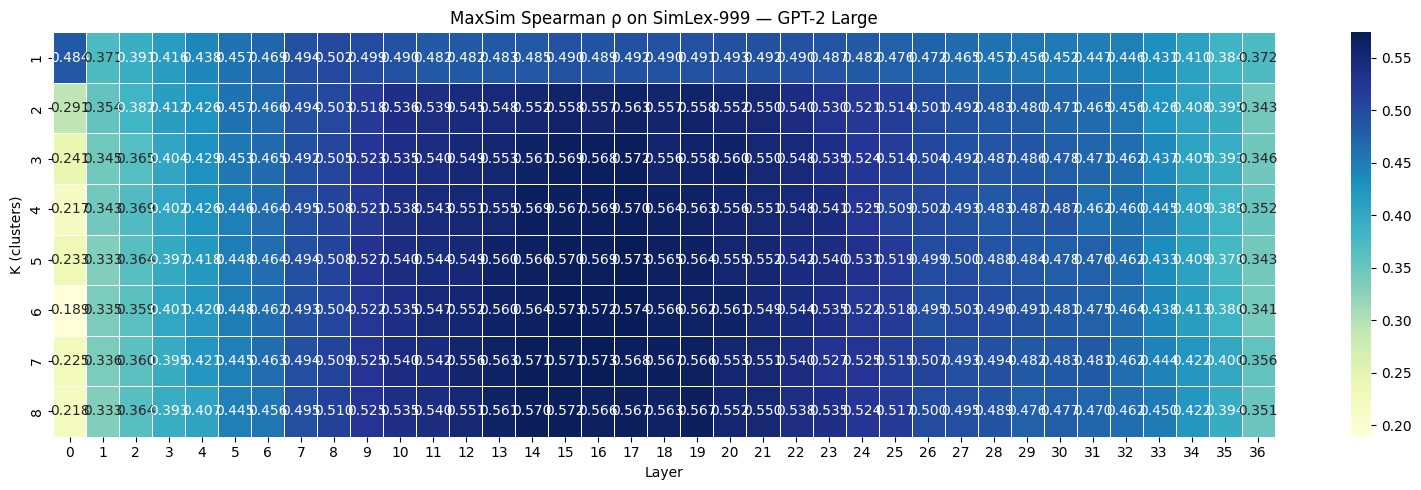

In [19]:
GPT2_SIMLEX_CSV = 'results_gpt2_simlex.csv'

if os.path.exists(GPT2_SIMLEX_CSV):
    df_heat = pd.read_csv(GPT2_SIMLEX_CSV, index_col=0)
    df_heat.columns = df_heat.columns.astype(int)
    print(f"Loaded {GPT2_SIMLEX_CSV}")
else:
    K_values = [1, 2, 3, 4, 5, 6, 7, 8]

    valid_pairs = [
        (row['word1'], row['word2'])
        for row in simlex999
        if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
    ]
    human_sims = [
        float(row['SimLex999'])
        for row in simlex999
        if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
    ]
    print(f"Valid pairs: {len(valid_pairs)}/999")

    heatmap_data = []
    for K in tqdm(K_values, desc="K values"):
        for layer_idx in tqdm(range(37), desc=f"K={K} layers", leave=False):
            model_scores = [max_sim(w1, w2, layer_idx, K=K) for w1, w2 in valid_pairs]
            rho, _ = spearmanr(model_scores, human_sims)
            heatmap_data.append({'k_clusters': K, 'layer': layer_idx, 'spearman': round(rho, 3)})

    df_heat = pd.DataFrame(heatmap_data).pivot(index='k_clusters', columns='layer', values='spearman')
    df_heat.to_csv(GPT2_SIMLEX_CSV)
    print(f"Saved {GPT2_SIMLEX_CSV}")

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(df_heat, annot=True, fmt='.3f', linewidths=0.5, ax=ax, cmap='YlGnBu', square=False)
ax.set_title('MaxSim Spearman ρ on SimLex-999 — GPT-2 Large')
ax.set_xlabel('Layer')
ax.set_ylabel('K (clusters)')
plt.tight_layout()
plt.show()

## MEN Relatedness Dataset

MEN contains 3,000 word pairs rated for *relatedness* rather than similarity — related words share a domain or tend to co-occur but need not be interchangeable in context. Words already embedded for SimLex-999 are reused; only the novel MEN words need new BNC collection and embedding, then merged into a combined vocabulary.

In [20]:
# Load MEN dataset and identify words not yet in all_layer_outputs_individual
men = datasets.get_men()

men_wordlist = list(set([row['word1'] for row in men] + [row['word2'] for row in men]))
men_new_words = [w for w in men_wordlist if w not in all_layer_outputs_individual]
print(f"MEN unique words: {len(men_wordlist)}, new (not yet embedded): {len(men_new_words)}")


processed 3000 word pairs from MEN relatedness dataset
MEN unique words: 751, new (not yet embedded): 524


In [21]:
MEN_BNC_PKL = 'bnc_examples_men.pkl'
GPT2_MEN_PKL = 'all_layer_outputs_individual_gpt2_men.pkl'

if os.path.exists(MEN_BNC_PKL):
    with open(MEN_BNC_PKL, 'rb') as f:
        bnc_examples_men = pickle.load(f)
else:
    bnc_examples_men = collect_bnc_examples(men_new_words)
    with open(MEN_BNC_PKL, 'wb') as f:
        pickle.dump(bnc_examples_men, f)

all_layer_outputs_individual_men = embed_words_batched(
    men_new_words, bnc_examples_men, model, tokenizer,
    checkpoint_path=GPT2_MEN_PKL,
)
print("Done. Saved to", GPT2_MEN_PKL)

all_layer_outputs_individual_combined = {**all_layer_outputs_individual, **all_layer_outputs_individual_men}
print(f"Combined vocab size: {len(all_layer_outputs_individual_combined)}")

Words to process: 524/524


Embedding words:   0%|          | 0/524 [00:00<?, ?it/s]

Checkpoint saved (50 words)
Checkpoint saved (100 words)
Checkpoint saved (150 words)
Checkpoint saved (199 words)
Checkpoint saved (249 words)
Checkpoint saved (299 words)
Checkpoint saved (349 words)
Checkpoint saved (399 words)
Checkpoint saved (449 words)
Checkpoint saved (499 words)
Done. Saved to all_layer_outputs_individual_gpt2_men.pkl
Combined vocab size: 1551


In [22]:
# Per-layer Spearman rho on MEN (fixed K=4, matching the SimLex analysis)
men_valid_pairs = [
    (row['word1'], row['word2'])
    for row in men
    if row['word1'] in all_layer_outputs_individual_combined and row['word2'] in all_layer_outputs_individual_combined
]
men_human_sims = [
    row['relatedness']
    for row in men
    if row['word1'] in all_layer_outputs_individual_combined and row['word2'] in all_layer_outputs_individual_combined
]
print(f"Valid MEN pairs: {len(men_valid_pairs)}/3000")

for layer_idx in tqdm(range(37), desc="Layers"):
    model_scores = [max_sim(w1, w2, layer_idx, K=4, outputs=all_layer_outputs_individual_combined)
                    for w1, w2 in men_valid_pairs]
    print(f"Layer {layer_idx} Spearman's p correlation is: {spearmanr(model_scores, men_human_sims)}")

Valid MEN pairs: 2998/3000


Layers:   0%|          | 0/37 [00:00<?, ?it/s]

Layer 0 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.30893145728217675), pvalue=np.float64(2.6096170392055974e-67))
Layer 1 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6292736416160982), pvalue=np.float64(0.0))
Layer 2 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6226894495702412), pvalue=np.float64(0.0))
Layer 3 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6489313110817131), pvalue=np.float64(0.0))
Layer 4 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6518605976347039), pvalue=np.float64(0.0))
Layer 5 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6751295076471239), pvalue=np.float64(0.0))
Layer 6 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6886298021156438), pvalue=np.float64(0.0))
Layer 7 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6947189188230926), pvalue=np.float64(0.0))
Laye

### MEN — K × Layer Heatmap

Same grid as SimLex-999: Spearman's ρ for each (K, layer) combination, now against MEN relatedness scores. Results cached to `results_gpt2_men.csv`.

Loaded results_gpt2_men.csv


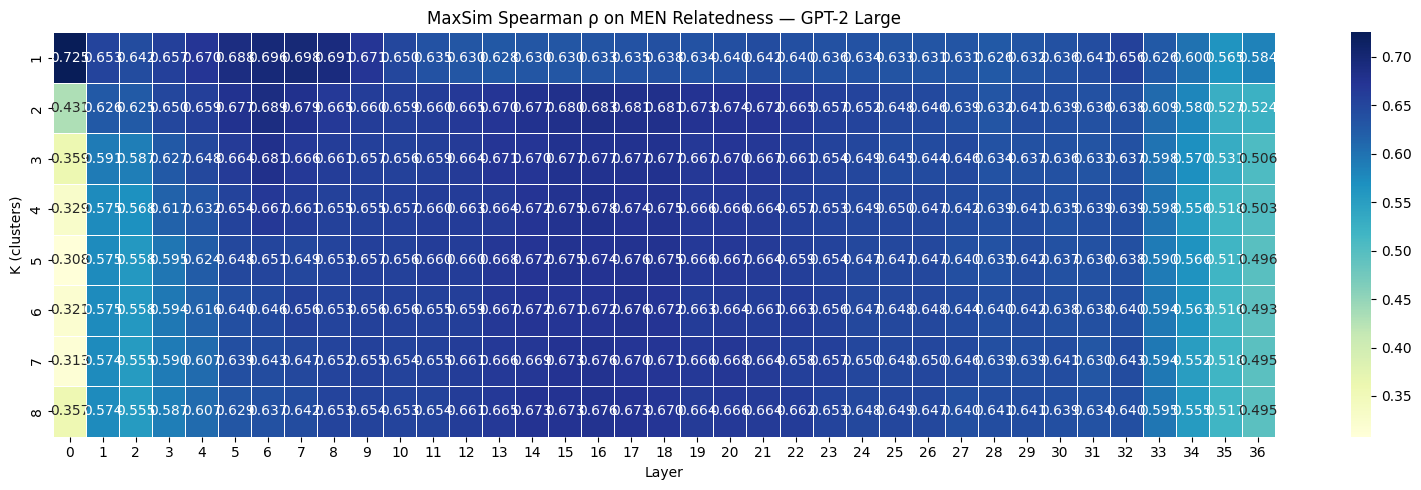

In [23]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
GPT2_MEN_CSV = 'results_gpt2_men.csv'

if os.path.exists(GPT2_MEN_CSV):
    df_heat_men = pd.read_csv(GPT2_MEN_CSV, index_col=0)
    df_heat_men.columns = df_heat_men.columns.astype(int)
    print(f"Loaded {GPT2_MEN_CSV}")
else:
    K_values = [1, 2, 3, 4, 5, 6, 7, 8]

    heatmap_data_men = []
    for K in tqdm(K_values, desc="K values"):
        for layer_idx in tqdm(range(37), desc=f"K={K} layers", leave=False):
            model_scores = [max_sim(w1, w2, layer_idx, K=K, outputs=all_layer_outputs_individual_combined)
                            for w1, w2 in men_valid_pairs]
            rho, _ = spearmanr(model_scores, men_human_sims)
            heatmap_data_men.append({'k_clusters': K, 'layer': layer_idx, 'spearman': round(rho, 3)})

    df_heat_men = pd.DataFrame(heatmap_data_men).pivot(index='k_clusters', columns='layer', values='spearman')
    df_heat_men.to_csv(GPT2_MEN_CSV)
    print(f"Saved {GPT2_MEN_CSV}")

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(df_heat_men, annot=True, fmt='.3f', linewidths=0.5, ax=ax, cmap='YlGnBu', square=False)
ax.set_title('MaxSim Spearman ρ on MEN Relatedness — GPT-2 Large')
ax.set_xlabel('Layer')
ax.set_ylabel('K (clusters)')
plt.tight_layout()
plt.show()

## Comparison with simple contextualized embeddings

In [24]:
# Simple contextualized embeddings: "The {} is here."
TEMPLATE = "The {} is here."
SIMPLE_PKL = 'simple_template_embeddings_gpt2.pkl'

def embed_words_simple(wordlist, model, tokenizer, template=TEMPLATE):
    embeddings = {}
    for word in tqdm(wordlist, desc="Embedding words"):
        sentence = template.format(word)
        enc = tokenizer(sentence, return_tensors="pt", return_offsets_mapping=True)
        offset_mapping = enc.pop("offset_mapping")[0]

        word_start = sentence.index(word)
        word_end = word_start + len(word)
        indices = [
            idx for idx, (tok_s, tok_e) in enumerate(offset_mapping.tolist())
            if tok_s < word_end and tok_e > word_start and tok_s < tok_e
        ]
        if not indices:
            continue

        inputs = {k: v.to(model.device) for k, v in enc.items()}
        with torch.no_grad():
            output = model(**inputs, output_hidden_states=True)

        layer_vecs = torch.stack([
            layer_hidden[0, indices, :].mean(dim=0).cpu()
            for layer_hidden in output.hidden_states
        ])
        embeddings[word] = layer_vecs
    return embeddings

if os.path.exists(SIMPLE_PKL):
    with open(SIMPLE_PKL, 'rb') as f:
        simple_embeddings = pickle.load(f)
    print(f"Loaded {SIMPLE_PKL}: {len(simple_embeddings)} words")
else:
    all_words = list(set(simlex999_wordlist + men_wordlist))
    simple_embeddings = embed_words_simple(all_words, model, tokenizer)
    with open(SIMPLE_PKL, 'wb') as f:
        pickle.dump(simple_embeddings, f)
    print(f"Saved {SIMPLE_PKL}")

Embedding words:   0%|          | 0/1552 [00:00<?, ?it/s]

Saved simple_template_embeddings_gpt2.pkl


### SimLex-999

Per-layer Spearman ρ using the simple template embedding. Cached to `results_gpt2_simple_simlex.csv`.

Valid pairs: 999/999


Layers:   0%|          | 0/37 [00:00<?, ?it/s]

Saved results_gpt2_simple_simlex.csv


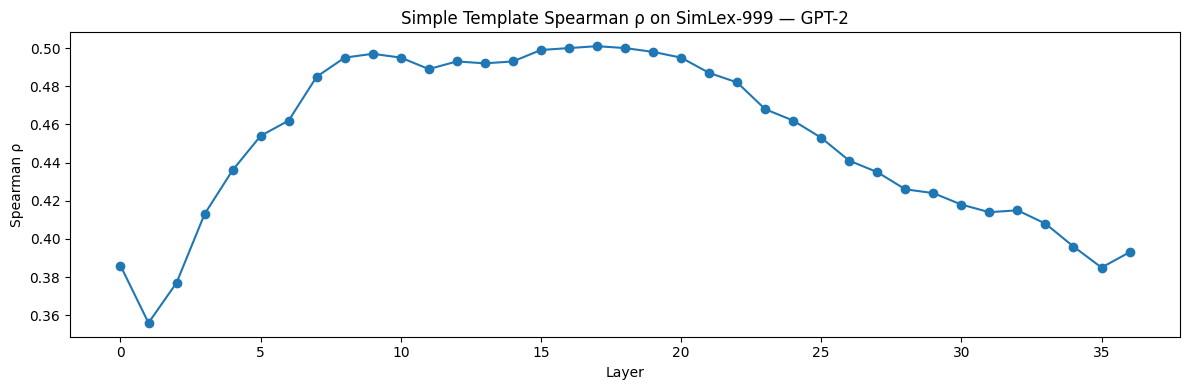

In [25]:
SIMPLE_SIMLEX_CSV = 'results_gpt2_simple_simlex.csv'

if os.path.exists(SIMPLE_SIMLEX_CSV):
    df_simple_simlex = pd.read_csv(SIMPLE_SIMLEX_CSV, index_col=0)
    print(f"Loaded {SIMPLE_SIMLEX_CSV}")
else:
    valid_pairs_simple = [
        (row['word1'], row['word2'])
        for row in simlex999
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    human_sims_simple = [
        float(row['SimLex999'])
        for row in simlex999
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    print(f"Valid pairs: {len(valid_pairs_simple)}/999")

    results = []
    for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
        model_scores = [
            float(torch.nn.functional.cosine_similarity(
                simple_embeddings[w1][layer_idx].unsqueeze(0),
                simple_embeddings[w2][layer_idx].unsqueeze(0)
            ))
            for w1, w2 in valid_pairs_simple
        ]
        rho, _ = spearmanr(model_scores, human_sims_simple)
        results.append({'layer': layer_idx, 'spearman': round(rho, 3)})

    df_simple_simlex = pd.DataFrame(results).set_index('layer')
    df_simple_simlex.to_csv(SIMPLE_SIMLEX_CSV)
    print(f"Saved {SIMPLE_SIMLEX_CSV}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_simple_simlex.index, df_simple_simlex['spearman'], marker='o')
ax.set_title('Simple Template Spearman ρ on SimLex-999 — GPT-2')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
plt.tight_layout()
plt.show()

### MEN

Per-layer Spearman ρ on MEN relatedness. Cached to `results_gpt2_simple_men.csv`.

Valid MEN pairs: 3000/3000


Layers:   0%|          | 0/37 [00:00<?, ?it/s]

Saved results_gpt2_simple_men.csv


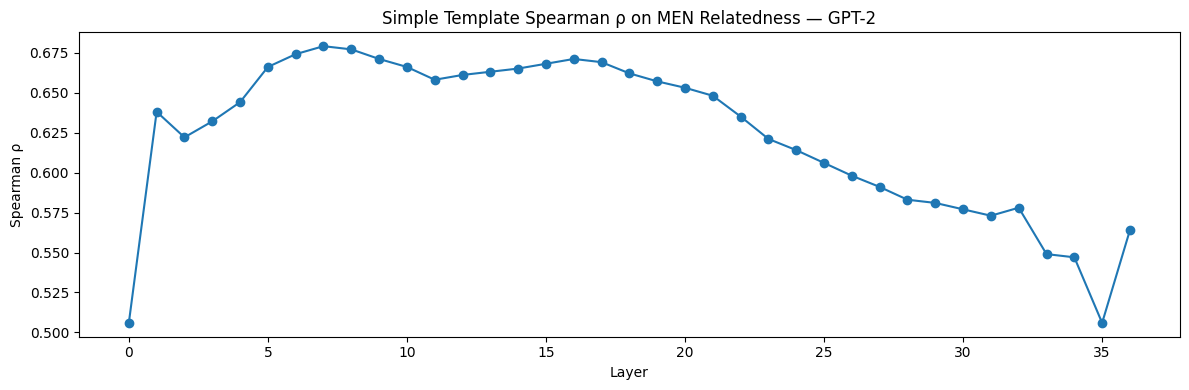

In [26]:
SIMPLE_MEN_CSV = 'results_gpt2_simple_men.csv'

if os.path.exists(SIMPLE_MEN_CSV):
    df_simple_men = pd.read_csv(SIMPLE_MEN_CSV, index_col=0)
    print(f"Loaded {SIMPLE_MEN_CSV}")
else:
    valid_pairs_simple_men = [
        (row['word1'], row['word2'])
        for row in men
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    human_sims_simple_men = [
        row['relatedness']
        for row in men
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    print(f"Valid MEN pairs: {len(valid_pairs_simple_men)}/3000")

    results_men = []
    for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
        model_scores = [
            float(torch.nn.functional.cosine_similarity(
                simple_embeddings[w1][layer_idx].unsqueeze(0),
                simple_embeddings[w2][layer_idx].unsqueeze(0)
            ))
            for w1, w2 in valid_pairs_simple_men
        ]
        rho, _ = spearmanr(model_scores, human_sims_simple_men)
        results_men.append({'layer': layer_idx, 'spearman': round(rho, 3)})

    df_simple_men = pd.DataFrame(results_men).set_index('layer')
    df_simple_men.to_csv(SIMPLE_MEN_CSV)
    print(f"Saved {SIMPLE_MEN_CSV}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_simple_men.index, df_simple_men['spearman'], marker='o')
ax.set_title('Simple Template Spearman ρ on MEN Relatedness — GPT-2')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
plt.tight_layout()
plt.show()

## Non-contextual Baselines

Each word is embedded in isolation (no surrounding context). Two variants:
- **Layer 0** (`hidden_states[0]`): token embedding before any transformer layers
- **Final layer** (`last_hidden_state`): full model pass with no context

Spearman ρ against SimLex-999 and MEN. Results saved to `results_gpt2_nonctx.csv`.

In [ ]:
NONCTX_CSV = 'results_gpt2_nonctx.csv'

if os.path.exists(NONCTX_CSV):
    df_nonctx = pd.read_csv(NONCTX_CSV, index_col=0)
    print(f"Loaded {NONCTX_CSV}")
else:
    all_words = list(set(simlex999_wordlist + men_wordlist))
    initial_embs, final_embs = {}, {}

    for word in tqdm(all_words, desc="Non-contextual embeddings"):
        inputs = tokenizer(word, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
        initial_embs[word] = out.hidden_states[0][0].mean(dim=0).float().cpu()
        final_embs[word] = out.last_hidden_state[0].mean(dim=0).float().cpu()

    def _spearman_cosine(embs, dataset, score_field):
        sims, human = [], []
        for r in dataset:
            w1, w2 = r['word1'], r['word2']
            if w1 in embs and w2 in embs:
                sims.append(torch.nn.functional.cosine_similarity(
                    embs[w1].unsqueeze(0), embs[w2].unsqueeze(0)
                ).item())
                human.append(float(r[score_field]))
        rho, _ = spearmanr(sims, human)
        return round(rho, 4)

    df_nonctx = pd.DataFrame([
        {'embedding': 'initial_layer_0',
         'simlex_rho': _spearman_cosine(initial_embs, simlex999, 'SimLex999'),
         'men_rho':    _spearman_cosine(initial_embs, men, 'relatedness')},
        {'embedding': 'final_layer',
         'simlex_rho': _spearman_cosine(final_embs, simlex999, 'SimLex999'),
         'men_rho':    _spearman_cosine(final_embs, men, 'relatedness')},
    ]).set_index('embedding')
    df_nonctx.to_csv(NONCTX_CSV)
    print(f"Saved {NONCTX_CSV}")

display(df_nonctx)